In [1]:
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

base_path = r"D:/sroie-ocr-information-extraction"

ocr_text_folder = os.path.join(base_path, "data_ocr/train/Text")
entity_folder = os.path.join(base_path, "data/train/entities")

In [2]:
# Load OCR Text and Entities

records = []

files = sorted(os.listdir(entity_folder))   # iterate over ground truth files

for file in files:

    ocr_path = os.path.join(ocr_text_folder, file)
    entity_path = os.path.join(entity_folder, file)

    if not os.path.exists(ocr_path):
        continue

    with open(ocr_path, "r", encoding="utf-8") as f:
        ocr_data = json.load(f)

    with open(entity_path, "r", encoding="utf-8") as f:
        entities = json.load(f)

    company = entities.get("company","").lower()
    address = entities.get("address","").lower()
    date = entities.get("date","")
    total = entities.get("total","")

    for item in ocr_data:

        text = item["text"]
        box = item["bbox"]

        # PaddleOCR box format: 4 corner points
        xs = [p[0] for p in box]
        ys = [p[1] for p in box]

        x_center = sum(xs) / len(xs)
        y_center = sum(ys) / len(ys)

        text_clean = text.lower()

        label = "other"

        # total
        if total and total in text:
            label = "total"

        # date pattern
        elif re.search(r"\d{2}[/-]\d{2}[/-]\d{2,4}", text):
            label = "date"

        # company keyword match
        elif company and any(word in text_clean for word in company.split()):
            label = "company"

        # address keyword match
        elif address and any(word in text_clean for word in address.split()):
            label = "address"

        records.append({
            "file": file,
            "text": text,
            "label": label,
            "x_center": x_center,
            "y_center": y_center
        })

df = pd.DataFrame(records)

print("Receipts processed:", df["file"].nunique())
print(df["label"].value_counts())

Receipts processed: 626
label
other      25682
address     2475
total       1542
company     1395
date         754
Name: count, dtype: int64


In [3]:
# Normalize Layout Coordinates 
# (0,0) → top left
# (1,1) → bottom right

df["x_norm"] = (df["x_center"] - df["x_center"].min()) / (df["x_center"].max() - df["x_center"].min())
df["y_norm"] = (df["y_center"] - df["y_center"].min()) / (df["y_center"].max() - df["y_center"].min())

In [4]:
# Compute line position and normalize

df = df.sort_values(["file", "y_center"]).reset_index(drop=True)

df["line_index"] = df.groupby("file").cumcount()

df["line_norm"] = df.groupby("file")["line_index"].transform(
    lambda x: x / x.max() if x.max() > 0 else 0
)

print(df.head())

       file                        text    label  x_center  y_center  \
0  000.json               tan woon yann  company    196.25     44.75   
1  000.json  BOOK TA KTAMANDAYA)SDN BHD  company    246.00    103.00   
2  000.json                    789417-W    other    247.00    129.00   
3  000.json      NO.55557&59JALANSAGU18  address    245.50    154.00   
4  000.json                  TAMANDAYA,  company    245.00    177.50   

     x_norm    y_norm  line_index  line_norm  
0  0.055308  0.004293           0   0.000000  
1  0.070615  0.013068           1   0.023810  
2  0.070923  0.016985           2   0.047619  
3  0.070462  0.020751           3   0.071429  
4  0.070308  0.024291           4   0.095238  


In [5]:
df

,file,text,label,x_center,y_center,x_norm,y_norm,line_index,line_norm
0,000.json,tan woon yann,company,196.25,44.75,0.055308,0.004293,0,0.000000
1,000.json,BOOK TA KTAMANDAYA)SDN BHD,company,246.00,103.00,0.070615,0.013068,1,0.023810
2,000.json,789417-W,other,247.00,129.00,0.070923,0.016985,2,0.047619
3,000.json,NO.55557&59JALANSAGU18,address,245.50,154.00,0.070462,0.020751,3,0.071429
4,000.json,"TAMANDAYA,",company,245.00,177.50,0.070308,0.024291,4,0.095238
...,...,...,...,...,...,...,...,...,...
31843,625.json,0.68,other,461.00,780.50,0.136769,0.115128,37,0.902439
31844,625.json,11.32,other,343.00,781.00,0.100462,0.115204,38,0.926829
31845,625.json,Total,other,146.00,781.50,0.039846,0.115279,39,0.951220
31846,625.json,THANK YOU,other,301.00,819.00,0.087538,0.120928,40,0.975610


# Layout EDA

In [6]:
# Entity Layout Heatmaps

def plot_heatmap(label):

    subset = df[df["label"] == label]

    plt.figure(figsize=(6,6))

    sns.kdeplot(
        x=subset["x_norm"],
        y=subset["y_norm"],
        fill=True,
        cmap="Reds",
        bw_adjust=0.5,
        thresh=0.05
    )

    plt.title(f"{label.upper()} Layout Heatmap")

    plt.xlim(0,1)
    plt.ylim(1,0)

    plt.xlabel("X position")
    plt.ylabel("Y position")

    plt.show()

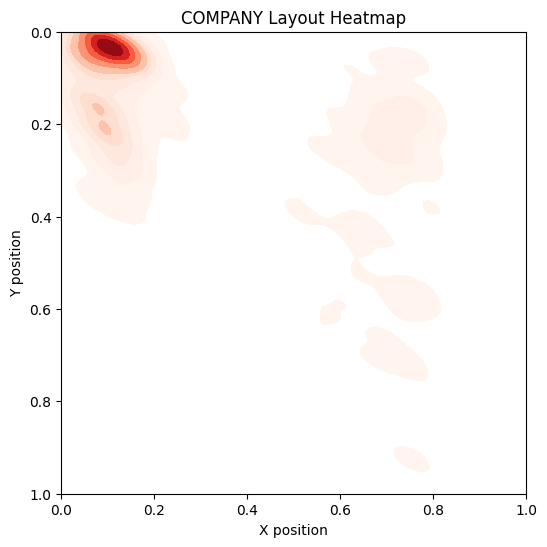

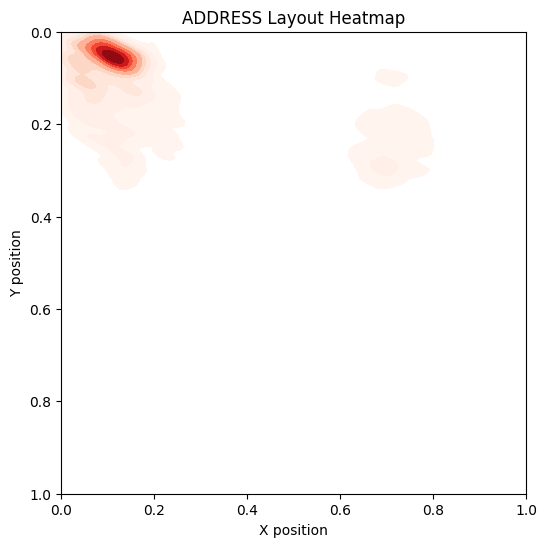

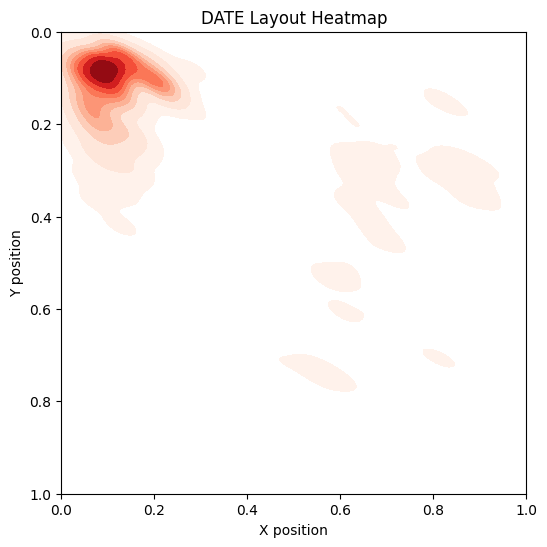

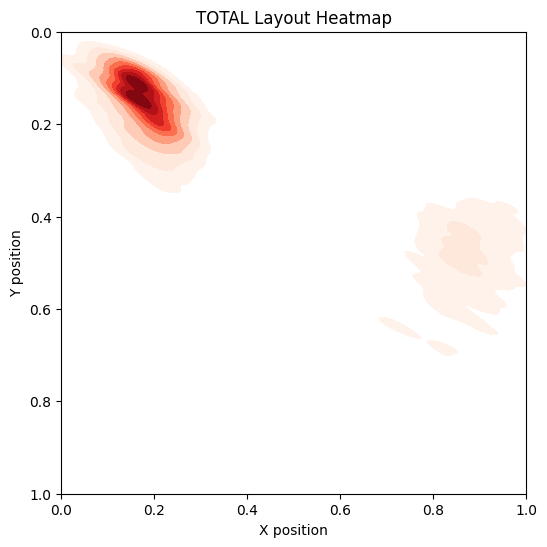

In [7]:
plot_heatmap("company")
plot_heatmap("address")
plot_heatmap("date")
plot_heatmap("total")

In [8]:
def grid_heatmap(label):

    subset = df[df["label"] == label]

    heatmap, xedges, yedges = np.histogram2d(
        subset["x_norm"],
        subset["y_norm"],
        bins=20
    )

    plt.figure(figsize=(6,6))

    sns.heatmap(heatmap.T, cmap="Reds")

    plt.title(f"{label.upper()} Density Grid")

    plt.xlabel("X grid")
    plt.ylabel("Y grid")

    plt.show()

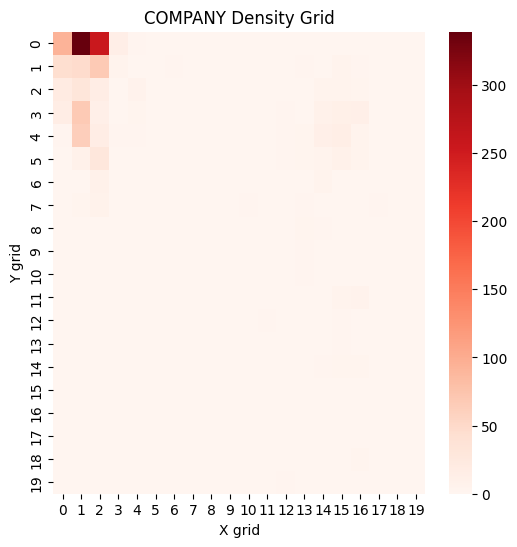

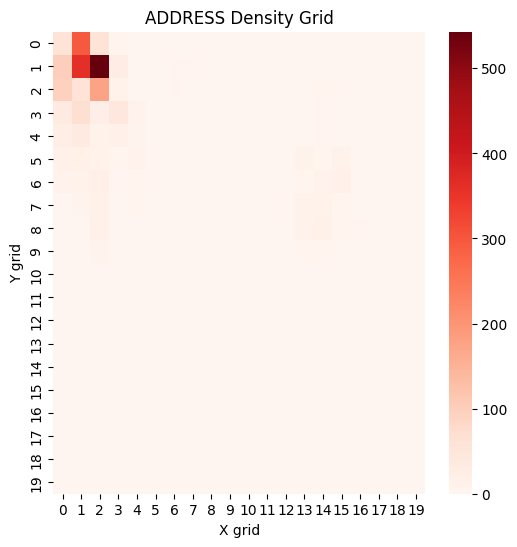

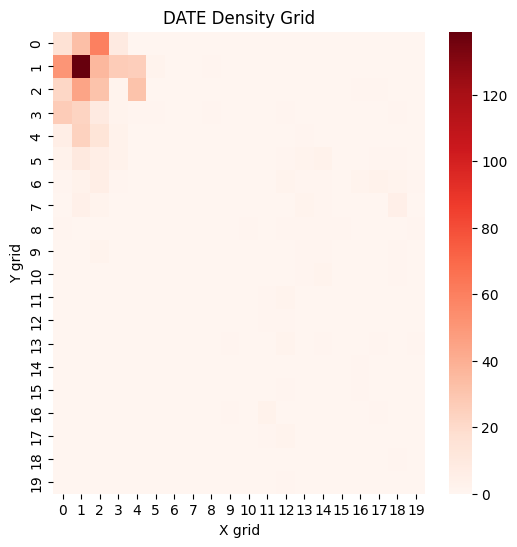

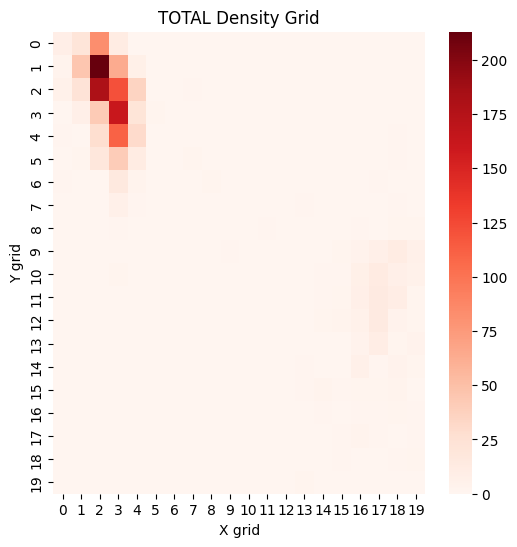

In [30]:
grid_heatmap("company")
grid_heatmap("address")
grid_heatmap("date")
grid_heatmap("total")

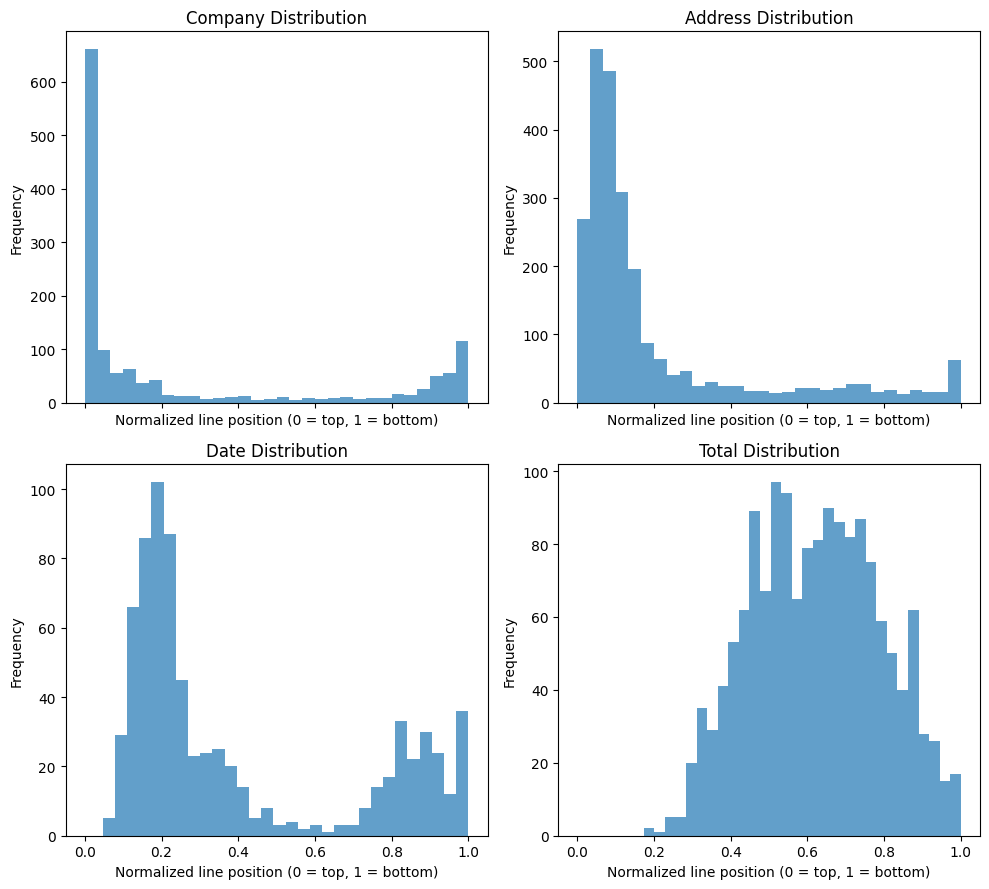

In [10]:
import matplotlib.pyplot as plt

labels = ["company", "address", "date", "total"]

fig, axes = plt.subplots(2, 2, figsize=(10,9), sharex=True)

axes = axes.flatten()

for i, label in enumerate(labels):

    subset = df[df["label"] == label]

    axes[i].hist(subset["line_norm"], bins=30, alpha=0.7)

    axes[i].set_title(f"{label.capitalize()} Distribution")
    axes[i].set_xlabel("Normalized line position (0 = top, 1 = bottom)")
    axes[i].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

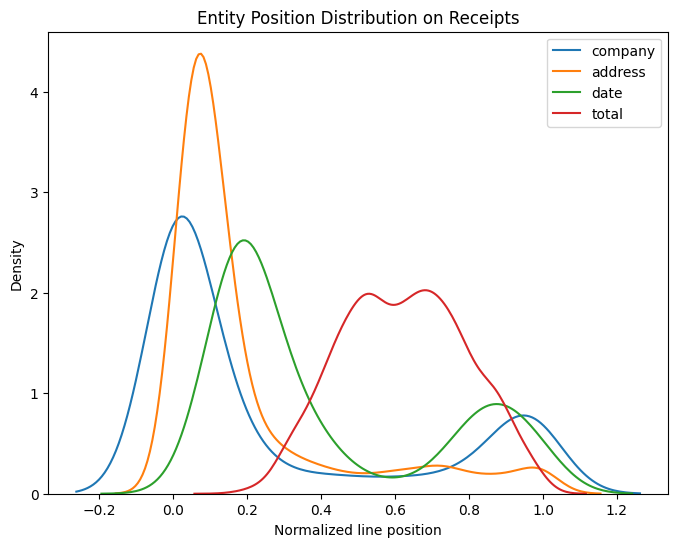

In [11]:
import seaborn as sns

plt.figure(figsize=(8,6))

for label in labels:
    subset = df[df["label"] == label]
    sns.kdeplot(subset["line_norm"], label=label)

plt.xlabel("Normalized line position")
plt.title("Entity Position Distribution on Receipts")
plt.legend()
plt.show()

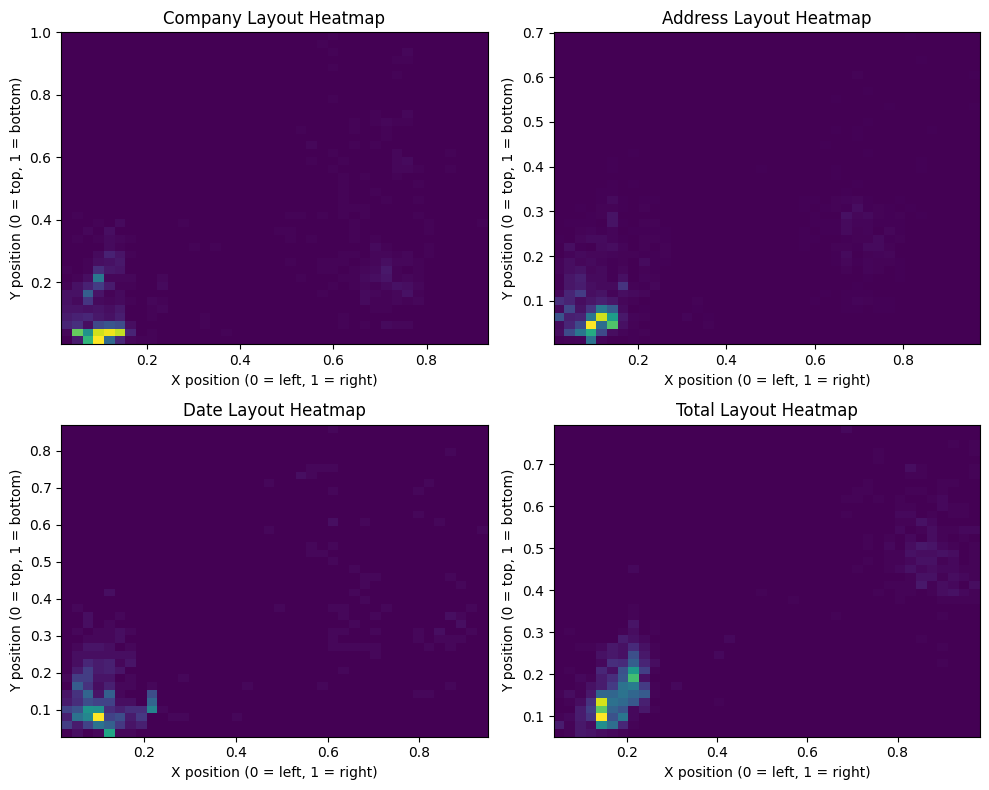

In [12]:
import matplotlib.pyplot as plt

labels = ["company", "address", "date", "total"]

fig, axes = plt.subplots(2, 2, figsize=(10,8))

axes = axes.flatten()

for i, label in enumerate(labels):

    subset = df[df["label"] == label]

    axes[i].hist2d(
        subset["x_norm"],
        subset["y_norm"],
        bins=40
    )

    axes[i].set_title(f"{label.capitalize()} Layout Heatmap")
    axes[i].set_xlabel("X position (0 = left, 1 = right)")
    axes[i].set_ylabel("Y position (0 = top, 1 = bottom)")

plt.tight_layout()
plt.show()

# Text pattern EDA

In [31]:
from collections import Counter
import re

def tokenize(text):
    text = text.lower()
    tokens = re.findall(r"[a-zA-Z0-9]+", text)
    return tokens


labels = ["company", "address", "date", "total"]

entity_keywords = {}

for label in labels:

    subset = df[df["label"] == label]

    words = []

    for text in subset["text"]:
        words.extend(tokenize(text))

    counter = Counter(words)

    keywords = [w for w,c in counter.most_common(100)]
    entity_keywords[label] = keywords


print(entity_keywords)

{'company': ['bhd', 'sdn', 's', 'gardenia', 'aeon', 'x', 'com', 'sanyu', 'the', 'i', 'products', 'stationery', 'd', 'fresh', 'co', 'makassar', 'mr', 'of', 'facebook', 'is', 'market', 'unihakka', 'international', 'kl', 'bakeries', 'no', 'recipient', 'k', 'm', 'follow', 'y', 'restaurant', 'popular', 'www', '139386', 'usin', 'restoran', 'my', '1135772', 'wan', 'sheng', 'perniagaan', 'taman', 'sanyustationeryshop', 'h', 'gst', 'one', 'total', 'cash', 'b519537', 'be', 'kee', 'enterprise', '1', 'syarikat', 'hardware', 'maluri', 'gin', 'tax', 'supply', 'sc', 'a', 'and', 'b', 'card', 'trading', 'permas', 'thank', 'you', '3rd', 'w', 'seafood', 'books', 'guardian', 'restaurants', 'for', 'flr', 'jaya', '300', 'city', 'three', 'msdnbhd', 'bandar', 'book', 'at', '80', 'son', 'tel', 'member', 'popularonline', '126926', 'invoice', 'tebrau', '99speedmarts', 'buy', 'msdn', 't', 'cashier', 'jalan', '113825'], 'address': ['no', 'jalan', 'selangor', '1', 'johor', 'alam', 'lot', 'lumpur', 'kuala', 'kawasan

In [32]:
for entity in entity_keywords:
    print(f"===={entity}====")
    print(entity_keywords[entity])

====company====
['bhd', 'sdn', 's', 'gardenia', 'aeon', 'x', 'com', 'sanyu', 'the', 'i', 'products', 'stationery', 'd', 'fresh', 'co', 'makassar', 'mr', 'of', 'facebook', 'is', 'market', 'unihakka', 'international', 'kl', 'bakeries', 'no', 'recipient', 'k', 'm', 'follow', 'y', 'restaurant', 'popular', 'www', '139386', 'usin', 'restoran', 'my', '1135772', 'wan', 'sheng', 'perniagaan', 'taman', 'sanyustationeryshop', 'h', 'gst', 'one', 'total', 'cash', 'b519537', 'be', 'kee', 'enterprise', '1', 'syarikat', 'hardware', 'maluri', 'gin', 'tax', 'supply', 'sc', 'a', 'and', 'b', 'card', 'trading', 'permas', 'thank', 'you', '3rd', 'w', 'seafood', 'books', 'guardian', 'restaurants', 'for', 'flr', 'jaya', '300', 'city', 'three', 'msdnbhd', 'bandar', 'book', 'at', '80', 'son', 'tel', 'member', 'popularonline', '126926', 'invoice', 'tebrau', '99speedmarts', 'buy', 'msdn', 't', 'cashier', 'jalan', '113825']
====address====
['no', 'jalan', 'selangor', '1', 'johor', 'alam', 'lot', 'lumpur', 'kuala', 

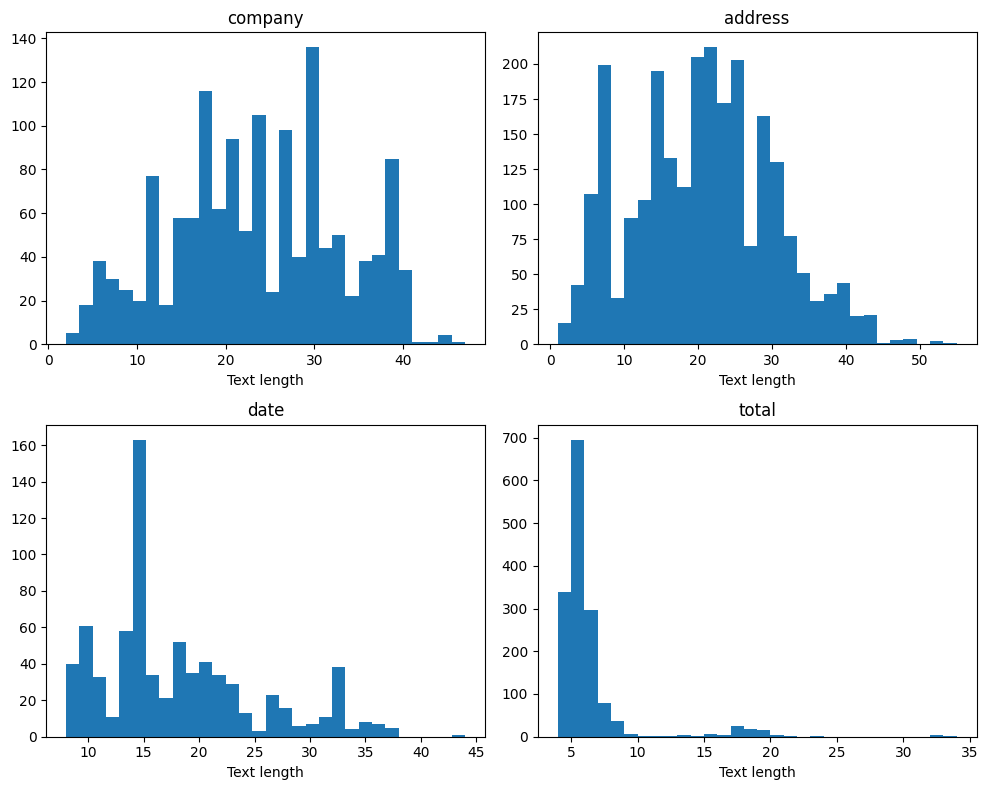

In [33]:
# Text length distribution

df["text_length"] = df["text"].str.len()

import matplotlib.pyplot as plt

labels = ["company","address","date","total"]

fig, axes = plt.subplots(2,2, figsize=(10,8))
axes = axes.flatten()

for i,label in enumerate(labels):

    subset = df[df["label"] == label]

    axes[i].hist(subset["text_length"], bins=30)

    axes[i].set_title(label)
    axes[i].set_xlabel("Text length")

plt.tight_layout()
plt.show()

In [ ]:
from collections import Counter
import re

# Find keywords for each entities

def tokenize(text):
    text = text.lower()
    tokens = re.findall(r"[a-zA-Z0-9]+", text)
    return tokens


labels = ["company","address","date","total"]

for label in labels:

    subset = df[df["label"] == label]

    words = []

    for text in subfrom collections import Counter
import re

def tokenize(text):
    text = text.lower()
    tokens = re.findall(r"[a-zA-Z0-9]+", text)
    return tokens


labels = ["company", "address", "date", "total"]

entity_keywords = {}

for label in labels:

    subset = df[df["label"] == label]

    words = []

    for text in subset["text"]:
        words.extend(tokenize(text))

    counter = Counter(words)

    # keep top 20 keywords
    top_keywords = [w for w, c in counter.most_common(20)]

    entity_keywords[label] = top_keywords


print(entity_keywords)set["text"]:
        words.extend(tokenize(text))

    counter = Counter(words)

    print("\n======", label.upper(), "======")
    print(counter.most_common(20))


====== COMPANY ======
[('bhd', 356), ('sdn', 305), ('s', 84), ('gardenia', 82), ('aeon', 71), ('x', 70), ('com', 59), ('sanyu', 58), ('the', 57), ('i', 48), ('products', 48), ('stationery', 47), ('d', 46), ('fresh', 46), ('co', 45), ('makassar', 45), ('mr', 44), ('of', 44), ('facebook', 43), ('is', 42)]

====== ADDRESS ======
[('no', 347), ('jalan', 268), ('selangor', 195), ('1', 127), ('johor', 116), ('alam', 108), ('lot', 107), ('lumpur', 89), ('kuala', 86), ('kawasan', 85), ('shah', 83), ('taman', 82), ('3', 80), ('perindustrian', 79), ('1851', 76), ('bandar', 76), ('tampoi', 74), ('gst', 73), ('9', 72), ('tax', 67)]

====== DATE ======
[('2018', 178), ('2017', 168), ('03', 149), ('06', 119), ('date', 116), ('04', 112), ('18', 110), ('12', 101), ('05', 98), ('10', 95), ('02', 82), ('09', 74), ('01', 73), ('11', 53), ('20', 52), ('07', 52), ('19', 51), ('17', 51), ('08', 50), ('13', 39)]

====== TOTAL ======
[('00', 443), ('20', 121), ('90', 115), ('70', 110), ('8', 103), ('50', 102

In [15]:
counter

Counter({'00': 443,
         '20': 121,
         '90': 115,
         '70': 110,
         '8': 103,
         '50': 102,
         '80': 96,
         '60': 91,
         '10': 88,
         '30': 80,
         '7': 79,
         '40': 77,
         'total': 65,
         '4': 63,
         '6': 50,
         '5': 49,
         '15': 46,
         '9': 44,
         '12': 44,
         '2': 39,
         'nett': 36,
         '35': 35,
         '45': 33,
         '25': 30,
         'amount': 28,
         '3': 27,
         '21': 25,
         '28': 25,
         '14': 21,
         '95': 20,
         '31': 19,
         '13': 19,
         '11': 19,
         '39': 18,
         '75': 18,
         '29': 18,
         '68': 17,
         '85': 16,
         '19': 16,
         '42': 15,
         '148': 15,
         '36': 15,
         '38': 15,
         '18': 14,
         '41': 14,
         '1': 14,
         '52': 14,
         '73': 13,
         '87': 13,
         '100': 12,
         '48': 12,
         'rm': 12,
    

In [ ]:
labels = ["company","address","date","total"]

for label in labels:
from collections import Counter
import re

def tokenize(text):
    text = text.lower()
    tokens = re.findall(r"[a-zA-Z0-9]+", text)
    return tokens


labels = ["company","address","date","total"]

for label in labels:

    subset = df[df["label"] == label]

    words = []

    for text in subset["text"]:
        words.extend(tokenize(text))

    counter = Counter(words)

    print("\n======", label.upper(), "======")
    print(counter.most_common(20))from collections import Counter
import re

def tokenize(text):
    text = text.lower()
    tokens = re.findall(r"[a-zA-Z0-9]+", text)
    return tokens


labels = ["company","address","date","total"]

for label in labels:

    subset = df[df["label"] == label]

    words = []

    for text in subset["text"]:
        words.extend(tokenize(text))

    counter = Counter(words)

    print("\n======", label.upper(), "======")
    print(counter.most_common(20))
    print("\n======", label, "======")

    samples = df[df["label"] == label]["text"].dropna().unique()[:20]

    for s in samples:
        print(s)


====== company ======
tan woon yann
BOOK TA KTAMANDAYA)SDN BHD
TAMANDAYA,
Total:
Roundd TotaiRM
INDAH GIFT & HOME DECO
ST-PRIVILEGE CARD/GD INDAH
MRD.I.Y.JOHORSDN BHD
MR DIY TESCO TERBAU
YONGFATT ENTERPRISE
MR D.I.Y.M SONBHD
ABC HO TRADING
81100 JOHOR BAHRU.JOHOR
SOON HUAT MACHINERY ENTERPRISE
SOONHUAT2000@HOTMAIL.COM
S.H.H.MOTORSUNGAI RENGITSDN.BHD
PERNIAGAAN ZHENG HUI
Gerbang Alaf Restaurants Sdn Bhd
Golden Arches Restaurants Sdn Bhd
SAM SAM TRADING CO

====== address ======
NO.55557&59JALANSAGU18
81100JOHOR BAHRU
JOHOR.
27JALAN DEDAP 13
TAMAN JOHOR JAYA,
81100 JOHOR BAHRUJOHOR.
LOT 1851-A&1851-BJALAN KPB6
KAWASAN PERINDUSTRIAN BALAKONG,
43300 SERI KEMBANGAN,SELANGOR
NO.122.124.JALANDEDAP13
81100 JOHORBAHRU
GSTID000849813504
DOC NO
GOODS SOLDARENOTREFUNDABLE.ONLY
10T 1851-A&1851-B.JALAN KPB6
43300 SERI KEMBANGANSELANGOR
TESCO PUTRA NILAI
KILAT'AUTO ECO WASH & SHINE ES1OOO IL
KILAIECO AUTQ NASH &WAX EW-1OQO-1L
No.2&43ALAN HARMONI3/2,

====== date ======
25/12/20188:13:39PM
19/10/2018

In [43]:
from collections import Counter

def keyword_freq(label):

    words = []

    for text in df[df["label"] == label]["text"].dropna():
        words += text.lower().split()

    return Counter(words).most_common(20)


print("Address keywords:")
print(keyword_freq("address"))

print("\nTotal keywords:")
print(keyword_freq("total"))

Address keywords:
[('jalan', 144), ('lot', 104), ('shah', 83), ('perindustrian', 79), ('taman', 74), ('no', 73), ('johor', 65), ('kuala', 64), ('lumpur', 64), ('selangor', 62), ('gst', 56), ('seri', 53), ('43300', 51), ('alam', 51), ('bandar', 49), ('kawasan', 48), ('40300', 46), ('selangor.', 45), ('seksyen', 44), ('alam,', 42)]

Total keywords:
[('nett', 36), ('total:', 29), ('8.70', 29), ('total', 28), ('12.00', 24), ('$8.20', 23), ('7.00', 23), ('amount:', 19), ('6.00', 18), ('4.80', 16), ('15.00', 15), ('4.60', 15), ('5.00', 14), ('50.00', 14), ('35.00', 13), ('6.70', 12), ('rm', 12), ('15.90', 11), ('31.00', 10), ('$8.70', 10)]


In [44]:
import re
import pandas as pd

def pattern_stats(label):

    subset = df[df["label"] == label]["text"].dropna()

    stats = []

    for text in subset:

        stats.append({
            "digits": bool(re.search(r"\d", text)),
            "letters": bool(re.search(r"[A-Za-z]", text)),
            "symbols": bool(re.search(r"[^\w\s]", text)),
            "length": len(text)
        })

    return pd.DataFrame(stats).mean()


for label in ["company","address","date","total"]:

    print("\n",label)
    print(pattern_stats(label))


 company
digits      0.287455
letters     0.994265
symbols     0.524014
length     23.292473
dtype: float64

 address
digits      0.728081
letters     0.955152
symbols     0.711111
length     20.544242
dtype: float64

 date
digits      1.000000
letters     0.688329
symbols     1.000000
length     18.075597
dtype: float64

 total
digits     1.000000
letters    0.178988
symbols    1.000000
length     5.918936
dtype: float64


In [45]:
# Date format
dates = df[df["label"] == "date"]["text"].dropna().unique()

for d in dates[:30]:
    print(d)

25/12/20188:13:39PM
19/10/2018
12-01-1921:13SH01ZK09
Date.25/12/2018
PI12PJ11-46/300
18-11-18 13:58SH01ZI53
Date09/01/20198:0111PM
Date:11/01/2019
23-01-2019 13:14:15 PMPRINT BY:r0ot
Date:12/02/2018
ORD#50-REG#19-18/01/201810:27:03
Frid-y29-12-2017 Time :20:17
RECEIPT#CSP0393921 0ATE15/06/201
22/12/201714:03
12/28/201710:17:32PM
2017-12-2822:17PM
Date: 22/12/2017
Bil1 Date:20/12/2017
Bil1Start:20/12/201707:10:35PM
Closed Bi11:20/12/2017 07:10:51PM
Bil1 Date :20/11/2017
Bi11 Start:20/11/2017 03:55:07PM
ClosBi11:20/11/2017 03:55:56 PM
18/03/1815:170605102
06/03/2018
18/01/2018
NO43-45-47G
25/01/20181:22:56PM
Date17/01/2018
Receipt No.CS1801/26717Date15/01/2018


In [ ]:
DATE_PATTERN = r"\b(\d{1,2}[/-]\d{1,2}[/-]\d{2,4}|\d{4}[/-]\d{1,2}[/-]\d{1,2})\b"

In [51]:
# Total ammount pattern
totals = df[df["label"] == "total"]["text"]

import re

for t in totals[:20]:
    print(re.findall(r"\d{1,3}(?:,\d{3})*\.\d{2}", t))

['9.00']
['9.00']
['9.00']
['9.00']
['60.30']
['33.90']
['80.90']
['80.90']
['30.90']
['31.00']
['31.00']
['31.00']
['327.00']
['327.00']
['327.00']
['327.00']
['327.00']
['20.00']
['20.00']
['20.00']


In [50]:
totals.unique()

array(['9.00', '9.000', '60.30', 'RM33.90', '80.90', 'RM30.90', '31.00',
       '327.00', '20.00', '112.45', '26.60', 'RM14.10', '15.00', '15.009',
       '15.90', '15.00ZR', '32.70', '73.00', '39.80', '86.00 A', '86.00',
       '54.50', '4.90', '27.55', '55.10', '18.00', '153.35', 'RM37.10',
       '2.50', '21.20', 'Nett Total: $8.20', '$8.20', '75.005R', '75.00',
       'Total Amount$8.20', '332.30', 'TotalAmount:$8.20',
       'Tota Amount$8.20', 'Nett Total$8.20', '57.80', 'RM57.80', '13.10',
       '189.75', '343.95', '174.90', 'RM64.15', '190.00',
       'Nett Total$8.60', '$8.60', 'TotalAmount$6.90', '$6.90', '28.60',
       '170.00', '100.90', '8.00', '593.10', 'Total Amount$7.60',
       'Nett Total:$7.60', '$7.60', '10.00', '10.00ZRL',
       'ZRL0%GOODS10.00', 'Tota Amount:$9.20', 'Nett Total$9.20', '$9.20',
       '13.80', 'Total Amount:$8.70', 'Nett Total$8.70', '$8.70', '$7.10',
       'Total Amount$7.10', 'Ne Total$7.10', '7.60', '77.20', '129.30',
       'RM11.405', '11